# ***Mnist***

Set Matplotlib inline.

In [37]:
%matplotlib inline

Configure TensorFlow version.

In [38]:
try:
  # %tensorflow_version only exists in Colab.
  %tensorflow_version 2.x
except Exception:
  pass

Colab only includes TensorFlow 2.x; %tensorflow_version has no effect.


The output indicates that TensorFlow 2.x is the default version in Colab and that the command has no effect on the version.

Load MNIST dataset.

In [39]:
from keras.datasets import mnist
import numpy as np
(x_train, _), (x_test, _) = mnist.load_data()

Display autoencoder GIF.

![](https://raw.githubusercontent.com/lucmos/DLAI-s2-2020-tutorials/master/08/interp.gif)

Normalize and flatten images.

**We will normalize all values between 0 and 1 and we will flatten the 28x28 images into vectors of size 784.**

Normalize pixel values.

In [40]:

x_train = x_train/255.0
x_test = x_test/255.0
x_train.shape

(60000, 28, 28)

The shape of the training data after normalization is 60,000 images of 28x28 pixels.

Flatten image data.

In [41]:
x_train = x_train.reshape((len(x_train), np.prod(x_train.shape[1:])))
x_test = x_test.reshape((len(x_test), np.prod(x_test.shape[1:])))
print (x_train.shape)
print (x_test.shape)

(60000, 784)
(10000, 784)


Training images (60,000) and test images (10,000) are flattened into 784-pixel vectors. The code confirms the correct data transformation.

Calculate image dimension.

In [42]:
28*28

784

The calculated dimension for a flattened image is 784 pixels (28x28).

Verify flattened length.

In [43]:
len(x_train[0])

784

The length of the first training image vector is indeed 784, confirming the flattening.


#  **First AutoEncoder**

Explain autoencoder concept.

In [44]:
from tensorflow.keras.layers import Input, Dense
from tensorflow.keras.models import Model


In the context of deep learning we refer to autoencoders (AEs) as neural networks where the expected output coincides with the input and the architecture contains a bottleneck (see figure below). The bottleneck favour a precise behaviour; the first part of the AE, or **Encoder**, learns to distill the information useful to *distinguish* between input samples, a **latent code** sized as the limited bottleneck. This latent code is then taken in input by the second part of the network, the **Decoder**, which tries to reconstruct the original input. To accomplish this result, the Decoder should learn all the information about the domain of the data not useful to distinguish between samples, but needed to reconstruct them. The loss of a standard AE is simply a reconstruction loss, e.g. in the case of an image it is a comparison of each pixel, tipically with a cross-entropy.

Define dense autoencoder.

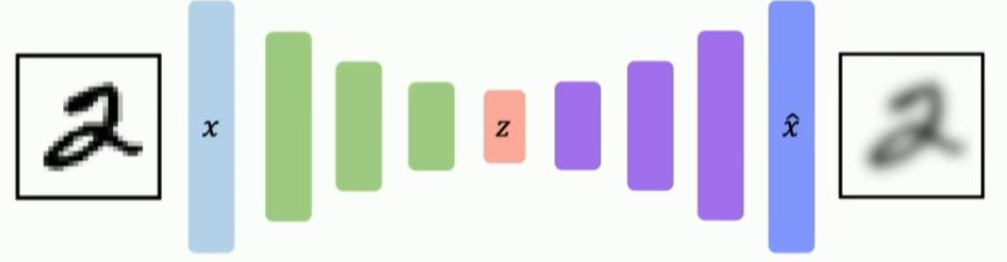

Create encoder model.

In [45]:

# this is the size of our encoded representations
encoding_dim = 10  # 32 floats -> compression of factor 24.5, assuming the input is 784 floats

# this is our input placeholder
input_img = Input(shape=(784,))
# "encoded" is the encoded representation of the input
encoded = Dense(encoding_dim, activation='relu')(input_img)
# "decoded" is the lossy reconstruction of the input
decoded = Dense(784, activation='sigmoid')(encoded)

# this model maps an input to its reconstruction
autoencoder = Model(input_img, decoded)

Let's also create a separate encoder model:
this model maps an input to its encoded representation


Compile autoencoder model.

In [46]:
encoder = Model(input_img, encoded)

Train autoencoder model.

As well as the decoder model:

Encode and decode images.

In [47]:
# create a placeholder for an encoded (32-dimensional) input
encoded_input = Input(shape=(encoding_dim,))
# retrieve the last layer of the autoencoder model
decoder_layer = autoencoder.layers[-1]
# create the decoder model
decoder = Model(encoded_input, decoder_layer(encoded_input))

Plot original and reconstructed.

Now let's train our autoencoder to reconstruct MNIST digits.

First, we'll configure our model to use a per-pixel binary crossentropy loss, and the Adadelta optimizer:

Reload and normalize MNIST.

In [48]:
autoencoder.compile(optimizer='adadelta', loss='binary_crossentropy')

Define convolutional autoencoder.

Training and validation losses decrease progressively over 50 epochs, indicating that the dense autoencoder is learning to reconstruct images. The final loss is 0.6858.

In [49]:
autoencoder.fit(x_train, x_train, epochs=50, batch_size=256, shuffle=True, validation_data=(x_test, x_test))

Epoch 1/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 4s 13ms/step - loss: 0.6931 - val_loss: 0.6931
Epoch 2/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.6931 - val_loss: 0.6930
Epoch 3/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.6930 - val_loss: 0.6930
Epoch 4/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.6929 - val_loss: 0.6929
Epoch 5/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.6929 - val_loss: 0.6928
Epoch 6/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.6928 - val_loss: 0.6928
Epoch 7/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.6927 - val_loss: 0.6927
Epoch 8/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.6926 - val_loss: 0.6926
Epoch 9/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.6926 - val_loss: 0.6926
Epoch 10/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.6925 - val_loss: 0.6925
Epoch 11/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.6924 - val_loss: 0.6924
Epoch 12/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/ste

The dense autoencoder's training history shows that both `loss` and `val_loss` remain very high and decrease only slightly over epochs (from 0.6931 to 0.6928 after 5 epochs). This behavior is a clear indication of underfitting.

Underfitting occurs when the model is too simple to capture the data's complexity or hasn't been trained enough. In this case, the autoencoder struggles to learn an effective representation for reconstruction.

Possible reasons include: the model architecture being too simple, the `adadelta` optimizer being inefficient with current hyperparameters, or insufficient training epochs (50) for a model learning so slowly with this optimizer.

We can try to visualize the reconstructed inputs and the encoded representationslib.

Check training data shape.

In [50]:
# encode and decode some digits
# note that we take them from the *test* set
encoded_imgs = encoder.predict(x_test)
decoded_imgs = decoder.predict(encoded_imgs)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


The autoencoder successfully processed the test set images to create encoded representations and decoded reconstructions.

Train convolutional autoencoder.

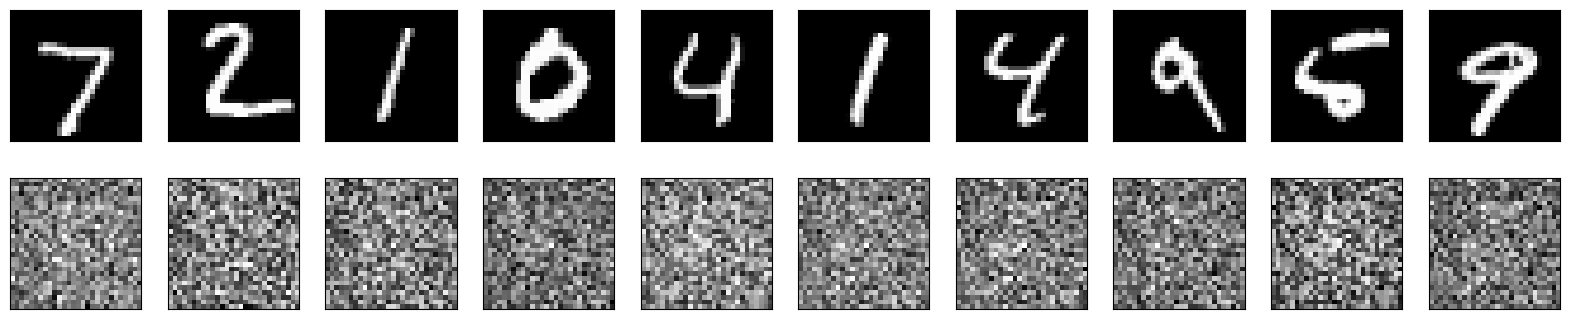

In [51]:
# use Matplotlib (don't ask)
import matplotlib.pyplot as plt

n = 10  # how many digits we will display
plt.figure(figsize=(20, 4))
for i in range(n):
    # display original
    ax = plt.subplot(2, n, i + 1)
    plt.imshow(x_test[i].reshape(28, 28))
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)

    # display reconstruction
    ax = plt.subplot(2, n, i + 1 + n)
    plt.gray()
    plt.imshow(decoded_imgs[i].reshape(28, 28))
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)
plt.show()

The graph shows a comparison between original images (top row) and their reconstructions by the dense autoencoder (bottom row). It is observed that the reconstructions are blurry and lack detail, which is expected for a dense autoencoder with a low encoding dimension (10). Furthermore, the images appear pixelated, likely due to the use of the `adadelta` optimizer; better results could potentially be obtained with the `adam` optimizer.

#  **ConvNet for AutoEncoder**





Explain denoising autoencoder.

In [52]:
(x_train, _), (x_test, _) = mnist.load_data()

x_train = x_train.astype('float32') / 255.
x_test = x_test.astype('float32') / 255.

In [54]:
from tensorflow.keras.layers import Input, Dense, Conv2D, MaxPooling2D, UpSampling2D
from tensorflow.keras.models import Model


input_img = Input(shape=(28, 28, 1))  # adapt this if using `channels_first` image data format

x = Conv2D(16, (3, 3), activation='relu', padding='same')(input_img)
x = MaxPooling2D((2, 2), padding='same')(x)
x = Conv2D(8, (3, 3), activation='relu', padding='same')(x)
x = MaxPooling2D((2, 2), padding='same')(x)
x = Conv2D(8, (3, 3), activation='relu', padding='same')(x)
encoded = MaxPooling2D((2, 2), padding='same')(x)

# at this point the representation is (4, 4, 8) i.e. 128-dimensional

# Decoder part
x = Conv2D(8, (3, 3), activation='relu', padding='same')(encoded)
x = UpSampling2D((2, 2))(x)
x = Conv2D(8, (3, 3), activation='relu', padding='same')(x)
x = UpSampling2D((2, 2))(x)
x = Conv2D(16, (3, 3), activation='relu', padding='same')(x)
x = UpSampling2D((2, 2))(x)
decoded = Conv2D(1, (5, 5), activation='sigmoid', padding='valid')(x)

autoencoder = Model(input_img, decoded)
autoencoder.compile(optimizer='adadelta', loss='binary_crossentropy')

In [55]:
autoencoder.summary()

Model: "functional_9"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_9 (InputLayer)      │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_21 (Conv2D)              │ (None, 28, 28, 16)     │           160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 14, 14, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_22 (Conv2D)              │ (None, 14, 14, 8)      │         1,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 7, 7, 8)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_23 (Conv2D)              │ (None, 7, 7, 8)        │           584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_9 (MaxPooling2D)  │ (None, 4, 4, 8)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_24 (Conv2D)              │ (None, 4, 4, 8)        │           584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_7 (UpSampling2D)  │ (None, 8, 8, 8)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_25 (Conv2D)              │ (None, 8, 8, 8)        │           584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_8 (UpSampling2D)  │ (None, 16, 16, 8)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_26 (Conv2D)              │ (None, 16, 16, 16)     │         1,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_9 (UpSampling2D)  │ (None, 32, 32, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_27 (Conv2D)              │ (None, 28, 28, 1)      │           401 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,641 (18.13 KB)

 Trainable params: 4,641 (18.13 KB)

 Non-trainable params: 0 (0.00 B)

This output describes the architecture of the convolutional autoencoder. It presents the types of layers (`Conv2D`, `MaxPooling2D`, `UpSampling2D`), their `Output Shape` (how data dimensions are transformed), and the `Param #` (trainable weights).

The encoder reduces spatial dimensions while increasing feature channels. The decoder reverses this process by upsampling to reconstruct the original image. The moderate number of parameters (`4,641` for this convolutional autoencoder) indicates efficiency for image tasks like MNIST, balancing learning capacity and preventing overfitting. This architecture is well-suited for image data processing.

Clip noisy pixel values.

In [56]:
x_train.shape

(60000, 28, 28)

The shape of the training data is 60,000 images, each 28x28 pixels.

Plot noisy images.

In [57]:
autoencoder.fit(x_train, x_train, epochs=50, batch_size=256, shuffle=True, validation_data=(x_test, x_test))

Epoch 1/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 10s 23ms/step - loss: 0.6829 - val_loss: 0.6809
Epoch 2/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 0.6783 - val_loss: 0.6752
Epoch 3/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.6709 - val_loss: 0.6657
Epoch 4/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.6581 - val_loss: 0.6489
Epoch 5/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.6352 - val_loss: 0.6188
Epoch 6/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 0.5943 - val_loss: 0.5668
Epoch 7/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 0.5347 - val_loss: 0.5083
Epoch 8/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 0.4911 - val_loss: 0.4844
Epoch 9/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.4776 - val_loss: 0.4778
Epoch 10/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.4720 - val_loss: 0.4728
Epoch 11/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 0.4671 - val_loss: 0.4679
Epoch 12/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/st

The training log for the convolutional autoencoder shows a clear and consistent decrease in both `loss` (training loss) and `val_loss` (validation loss) over 50 epochs (from 0.6829 to 0.2441). This strong reduction indicates that the model is effectively learning to reconstruct the input images.

Crucially, the validation loss closely follows the training loss. This suggests the model is generalizing well; it's learning patterns from the training data that apply effectively to unseen data. This is the opposite of overfitting, where a model learns the training data too well, including its noise, and performs poorly on new data. Unlike the previous dense autoencoder, which showed signs of underfitting (failing to learn the underlying patterns due to a high, stagnant loss), this convolutional architecture successfully captures image features and achieves a good balance without underfitting or overfitting.

Define denoising autoencoder.

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step


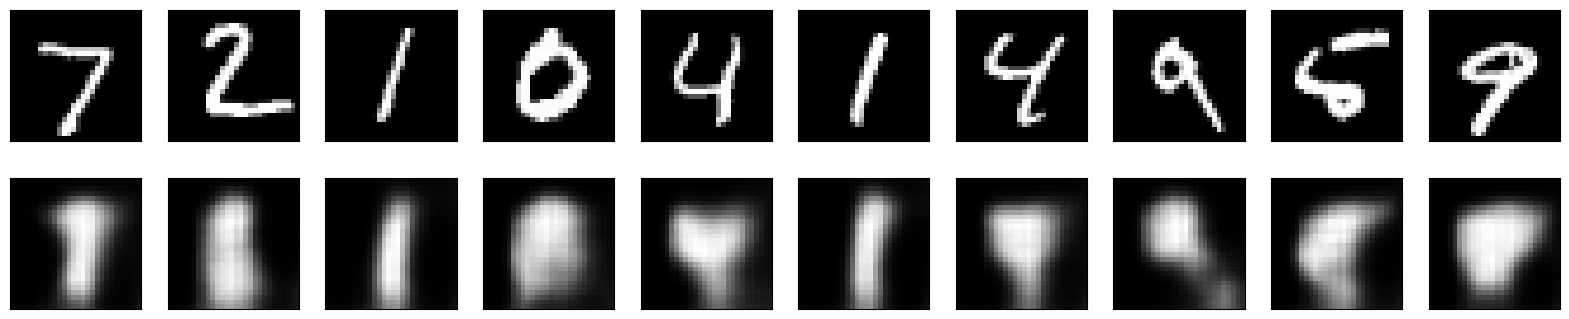

In [58]:
decoded_imgs = autoencoder.predict(x_test)

n = 10
plt.figure(figsize=(20, 4))
for i in range(n):
    # display original
    ax = plt.subplot(2, n, i+1)
    plt.imshow(x_test[i].reshape(28, 28))
    plt.gray()
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)

    # display reconstruction
    ax = plt.subplot(2, n, i +1+ n)
    plt.imshow(decoded_imgs[i].reshape(28, 28))
    plt.gray()
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)
plt.show()

The first row displays the original images, and the second row shows the reconstructed images from the convolutional autoencoder. These reconstructions demonstrate significantly improved quality compared to those from the dense autoencoder. The convolutional model effectively captures and retains the essential contours and shapes of the digits, resulting in much clearer and more recognizable outputs, rather than the blurry and pixelated results previously observed.

#  **Denoising AutoEncoder**

Denoising is one of the classic applications of autoencoders. The denoising process removes unwanted noise that corrupted the true signal.
Noise + Data ----> Denoising Autoencoder ----> Data.
Given a training dataset of corrupted data as input and true signal as output, a denoising autoencoder can recover the hidden structure to generate clean data. This example has modular design. The encoder, decoder and autoencoder are
3 models that share weights. For example, after training the autoencoder, the
encoder can be used to generate latent vectors of input data for low-dim visualization like PCA or TSNE.

Plot noisy and denoised.

Generate corrupted MNIST images by adding noise with normal distribution (mean = 0.0 and std= ) to your x_train and x_test dataset.

Illustrate VAE concept.

In [59]:
from keras.datasets import mnist
import numpy as np

(x_train, _), (x_test, _) = mnist.load_data()

x_train = x_train.astype('float32') / 255.
x_test = x_test.astype('float32') / 255.
x_train = np.reshape(x_train, (len(x_train), 28, 28, 1))  # adapt this if using `channels_first` image data format
x_test = np.reshape(x_test, (len(x_test), 28, 28, 1))  # adapt this if using `channels_first` image data format

noise_factor = 0.5
x_train_noisy = x_train + noise_factor * np.random.normal(loc=0.0, scale=1.0, size=x_train.shape)
x_test_noisy = x_test + noise_factor * np.random.normal(loc=0.0, scale=1.0, size=x_test.shape)



Explain VAE distributions.

After adding the random generated noises to the x sets, keep only those
among 0 and 1 using np.clip()/.

Intuition: encoding distributions.

In [60]:
x_train_noisy = np.clip(x_train_noisy, 0., 1.)
x_test_noisy = np.clip(x_test_noisy, 0., 1.)

Import Keras and TF.

it looks like

Define Sampling layer.

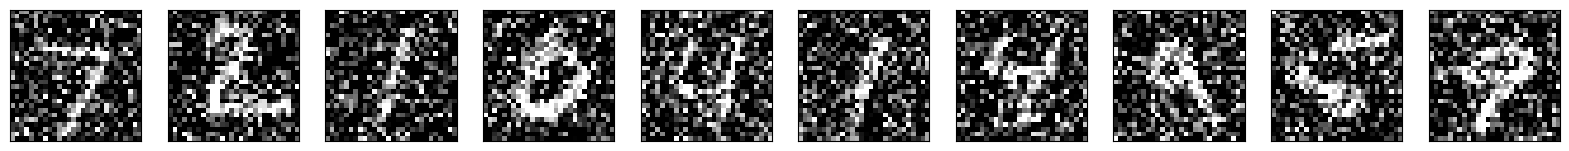

In [61]:
import matplotlib.pyplot as plt
n = 10
plt.figure(figsize=(20, 2))
for i in range(n):
    ax = plt.subplot(1, n, i+1)
    plt.imshow(x_test_noisy[i].reshape(28, 28))
    plt.gray()
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)
plt.show()

This display presents 10 examples of MNIST images, each corrupted by the addition of random noise. The images are significantly degraded, appearing speckled and obscured, which makes the original digits difficult to discern. This visually demonstrates the noisy input data that the denoising autoencoder will attempt to reconstruct.

Build VAE encoder.

Now build autoencoder to denoise images : use noised data in train to predict original images

Build VAE decoder.

In [63]:
from tensorflow.keras.layers import Conv2D, Input, MaxPooling2D, UpSampling2D

input_img = Input(shape=(28, 28, 1))  # adapt this if using `channels_first` image data format

x = Conv2D(32, (3, 3), activation='relu', padding='same')(input_img)
x = MaxPooling2D((2, 2), padding='same')(x)
x = Conv2D(32, (3, 3), activation='relu', padding='same')(x)
encoded = MaxPooling2D((2, 2), padding='same')(x)

# at this point the representation is (7, 7, 32)

x = Conv2D(32, (3, 3), activation='relu', padding='same')(encoded)
x = UpSampling2D((2, 2))(x)
x = Conv2D(32, (3, 3), activation='relu', padding='same')(x)
x = UpSampling2D((2, 2))(x)
decoded = Conv2D(1, (3, 3), activation='sigmoid', padding='same')(x)

autoencoder = Model(input_img, decoded)
autoencoder.compile(optimizer='adadelta', loss='binary_crossentropy')

Define VAE model.

In [64]:
autoencoder.summary()

Model: "functional_11"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_11 (InputLayer)     │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_33 (Conv2D)              │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_12 (MaxPooling2D) │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_34 (Conv2D)              │ (None, 14, 14, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_13 (MaxPooling2D) │ (None, 7, 7, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_35 (Conv2D)              │ (None, 7, 7, 32)       │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_12 (UpSampling2D) │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_36 (Conv2D)              │ (None, 14, 14, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_13 (UpSampling2D) │ (None, 28, 28, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_37 (Conv2D)              │ (None, 28, 28, 1)      │           289 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 28,353 (110.75 KB)

 Trainable params: 28,353 (110.75 KB)

 Non-trainable params: 0 (0.00 B)

This summary details the architecture of the denoising autoencoder. It consists of `Conv2D` layers for feature extraction and `MaxPooling2D` layers for downsampling in the encoder, reducing the input to a (7, 7, 32) latent space. The decoder then uses `Conv2D` and `UpSampling2D` layers to reconstruct the image. The `Output Shape` shows how dimensions change, and `Param #` indicates trainable weights for convolutional layers. The model has 28,353 trainable parameters, reflecting its capacity to learn and remove noise effectively from images.

Train VAE model.

In [65]:
autoencoder.fit(x_train_noisy, x_train, epochs=50, batch_size=256, shuffle=True, validation_data=(x_test_noisy, x_test))

Epoch 1/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 8s 22ms/step - loss: 0.6636 - val_loss: 0.6575
Epoch 2/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 0.6490 - val_loss: 0.6403
Epoch 3/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 0.6281 - val_loss: 0.6157
Epoch 4/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 0.5993 - val_loss: 0.5839
Epoch 5/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - loss: 0.5658 - val_loss: 0.5516
Epoch 6/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 0.5375 - val_loss: 0.5302
Epoch 7/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 0.5216 - val_loss: 0.5202
Epoch 8/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 0.5141 - val_loss: 0.5150
Epoch 9/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 0.5093 - val_loss: 0.5107
Epoch 10/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 0.5051 - val_loss: 0.5065
Epoch 11/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 0.5008 - val_loss: 0.5021
Epoch 12/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 

The training log for the denoising autoencoder clearly shows a consistent decrease in both `loss` and `val_loss` over 50 epochs (from 0.6636 to 0.1957). This strong and continuous reduction indicates that the model is effectively learning to reconstruct clean images from their noisy versions.

The training loss and validation loss decrease in tandem, staying close to each other. This signifies that the model is generalizing well; it's not just memorizing the training data but learning robust features to denoise unseen test images. This also suggests that the model is neither underfitting (as the loss is significantly decreasing) nor overfitting (as `val_loss` doesn't diverge much from `loss`), achieving a good balance in its learning process.

we compare now

Define latent space plot.

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step


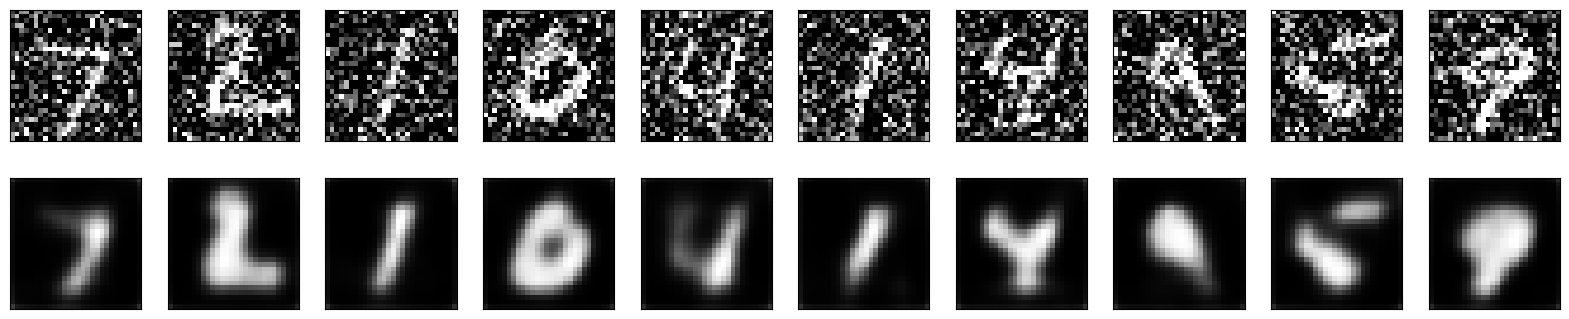

In [66]:
decoded_imgs = autoencoder.predict(x_test_noisy)

n = 10
plt.figure(figsize=(20, 4))
for i in range(n):
    # display original
    ax = plt.subplot(2, n, i+1)
    plt.imshow(x_test_noisy[i].reshape(28, 28))
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)

    # display reconstruction
    ax = plt.subplot(2, n, i +1+ n)
    plt.imshow(decoded_imgs[i].reshape(28, 28))
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)
plt.show()

This display offers a clear demonstration of the denoising autoencoder's effectiveness. The top row presents the input images, which are heavily corrupted with pervasive random noise, rendering the original MNIST digits barely recognizable and heavily obscured by speckles. In stark contrast, the bottom row showcases the images meticulously reconstructed by the denoising autoencoder. A dramatic improvement is evident: the denoised images have not only largely regained their original clarity but also exhibit significantly restored contours, shapes, and structural integrity of the digits. This remarkable transformation highlights the autoencoder's advanced capability to precisely distinguish and suppress noise, extracting the clean underlying signal from severely degraded inputs.

# ****Variational AutoEncoder****

Plot label clusters.

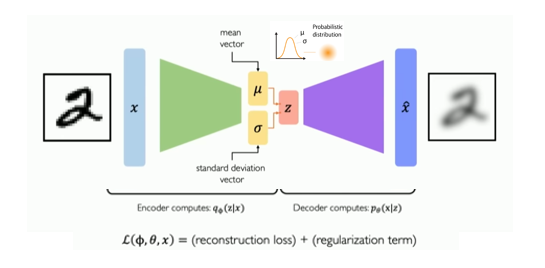

Rather than directly outputting values for the latent state as we would in a standard AE, the encoder model of a VAE outputs entire probability distributions, during training we sample from these distributions to obtain a latent code for the decoder.

Traditional **VAEs make the strong assumption on the distribution of latent codes as a multivariate Gaussian with a diagonal covariance structure**, so each component is normally distributed and indipendent from the others.

A $n$-dimensional gaussian is defined by a vector $(\mu_1, ... , \mu_n)$ and a covariance matrix $\Sigma \in \mathbb{R}^{n \times n}$. Since we are assuming independent components, $\Sigma$ is a diagonal matrix and we can describe it with a single vector of size $n$ containing the diagonal. Furthermore, the boundary of the Gaussian will assume a spherical shape (in the general case of arbitrary covariance matrices, it assumes an ellipsoidal shape).

So the Encoder of a VAE outputs two vectors collecting the means and the variances (instead of encoding the variance $\sigma^2$ we will work for convenience with the logarithm of the variance $log(\sigma^2)$).



**Intuition: encoding probability distributions**

Let's suppose we've trained an autoencoder model on a large dataset of faces with a encoding dimension of 6. An ideal autoencoder will learn descriptive attributes of faces such as skin color, whether or not the person is wearing glasses, etc. in an attempt to describe an observation in some compressed representation.

![](https://raw.githubusercontent.com/lucmos/DLAI-s2-2020-tutorials/master/08/int1.png)

In the example above, we've described the input image in terms of its latent attributes using a **single value to describe each attribute**.

However, we may prefer to represent each latent attribute as a range of possible values. For instance, what *single value* would you assign for the smile attribute if you feed in a photo of the Mona Lisa? Using a variational autoencoder, we can describe latent attributes in probabilistic terms.

![](https://raw.githubusercontent.com/lucmos/DLAI-s2-2020-tutorials/master/08/int2.png)


With this approach, we'll now represent each latent attribute for a given input as a probability distribution. When decoding from the latent state, we'll randomly sample from each latent state distribution to generate a vector as input for our decoder model.

![](https://raw.githubusercontent.com/lucmos/DLAI-s2-2020-tutorials/master/08/int3.png)

By constructing our encoder model to output a range of possible values (a statistical distribution) from which we'll randomly sample to feed into our decoder model, we're essentially enforcing a continuous, smooth latent space representation. For any sampling of the latent distributions, we're expecting our decoder model to be able to accurately reconstruct the input. Thus, values which are nearby to one another in latent space should correspond with very similar reconstructions.

![](https://raw.githubusercontent.com/lucmos/DLAI-s2-2020-tutorials/master/08/int4.png)


Import Keras and TensorFlow.

In [67]:
from tensorflow.keras import layers
import tensorflow as tf
from tensorflow import keras

Define Sampling layer.

In [68]:
#Create a sampling layer
class Sampling(layers.Layer):
    """Uses (z_mean, z_log_var) to sample z, the vector encoding a digit."""

    def call(self, inputs):
        z_mean, z_log_var = inputs
        batch = tf.shape(z_mean)[0]
        dim = tf.shape(z_mean)[1]
        epsilon = tf.keras.backend.random_normal(shape=(batch, dim))
        return z_mean + tf.exp(0.5 * z_log_var) * epsilon

Build the VAE encoder.

In [69]:
#Build the encoder
latent_dim = 2

encoder_inputs = keras.Input(shape=(28, 28, 1))
x = layers.Conv2D(32, 3, activation="relu", strides=2, padding="same")(encoder_inputs)
x = layers.Conv2D(64, 3, activation="relu", strides=2, padding="same")(x)
x = layers.Flatten()(x)
x = layers.Dense(16, activation="relu")(x)
z_mean = layers.Dense(latent_dim, name="z_mean")(x)
z_log_var = layers.Dense(latent_dim, name="z_log_var")(x)
z = Sampling()([z_mean, z_log_var])
encoder = keras.Model(encoder_inputs, [z_mean, z_log_var, z], name="encoder")
encoder.summary()

Model: "encoder"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_12      │ (None, 28, 28, 1) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_38 (Conv2D)  │ (None, 14, 14,    │        320 │ input_layer_12[0… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_39 (Conv2D)  │ (None, 7, 7, 64)  │     18,496 │ conv2d_38[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten_1 (Flatten) │ (None, 3136)      │          0 │ conv2d_39[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_6 (Dense)     │ (None, 16)        │     50,192 │ flatten_1[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ z_mean (Dense)      │ (None, 2)         │         34 │ dense_6[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ z_log_var (Dense)   │ (None, 2)         │         34 │ dense_6[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ sampling_1          │ (None, 2)         │          0 │ z_mean[0][0],     │
│ (Sampling)          │                   │            │ z_log_var[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 69,076 (269.83 KB)

 Trainable params: 69,076 (269.83 KB)

 Non-trainable params: 0 (0.00 B)

This output provides a precise summary of the Variational Autoencoder (VAE) encoder model's architecture. It details how the input image (28x28x1) is processed:

*   **`input_layer_12`**: Receives the 28x28 grayscale image.
*   **`conv2d_38` & `conv2d_39`**: These convolutional layers extract features and downsample the image (stride=2), progressively reducing spatial dimensions while increasing feature maps (to 32 and then 64). `Param #` reflects their learned filters.
*   **`flatten_1`**: Converts the 3D feature maps (e.g., 7x7x64) into a 1D vector (3136 elements) for the dense layers.
*   **`dense_6`**: A fully connected layer that further processes the flattened features.
*   **`z_mean` & `z_log_var`**: These two `Dense` layers output the mean and log-variance for the 2-dimensional latent space. Crucially, in a VAE, the encoder outputs these distributions, not a single point.
*   **`sampling_1`**: This custom layer samples a latent vector `z` from the Gaussian distribution defined by `z_mean` and `z_log_var`. This reparameterization trick allows gradients to flow through the sampling process.

The encoder transforms the input into these probabilistic latent representations, with a total of 69,076 trainable parameters.

Build the VAE decoder.

In [70]:
#Build the decoder
latent_inputs = keras.Input(shape=(latent_dim,))
x = layers.Dense(7 * 7 * 64, activation="relu")(latent_inputs)
x = layers.Reshape((7, 7, 64))(x)
x = layers.Conv2DTranspose(64, 3, activation="relu", strides=2, padding="same")(x)
x = layers.Conv2DTranspose(32, 3, activation="relu", strides=2, padding="same")(x)
decoder_outputs = layers.Conv2DTranspose(1, 3, activation="sigmoid", padding="same")(x)
decoder = keras.Model(latent_inputs, decoder_outputs, name="decoder")
decoder.summary()


Model: "decoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_13 (InputLayer)     │ (None, 2)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 3136)           │         9,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape_1 (Reshape)             │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_3              │ (None, 14, 14, 64)     │        36,928 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_4              │ (None, 28, 28, 32)     │        18,464 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_5              │ (None, 28, 28, 1)      │           289 │
│ (Conv2DTranspose)               │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 65,089 (254.25 KB)

 Trainable params: 65,089 (254.25 KB)

 Non-trainable params: 0 (0.00 B)

This output presents the architecture of the Variational Autoencoder (VAE) decoder model, detailing the transformation of a latent vector into a reconstructed image:

*   **`input_layer_13`**: This is the input layer of the decoder. It receives the latent vector `z` (of dimension `2`) sampled from the latent space.
*   **`dense_7`**: This dense layer takes the 2-dimensional latent vector and expands it to a larger dimension (3136 elements, corresponding to 7x7x64). This prepares the data for reshaping into a spatial form.
*   **`reshape_1`**: Reshapes the 1D vector of 3136 elements into a 3D tensor of 7x7x64. This form serves as the base for "upsampling" operations by the deconvolution layers.
*   **`conv2d_transpose_3`**: First transposed convolution layer (often called deconvolution). It upsamples the input shape from 7x7 to 14x14 and uses 64 filters, progressively reconstructing spatial features.
*   **`conv2d_transpose_4`**: Second transposed convolution layer. It continues upsampling, transforming the input from 14x14 to 28x28, and uses 32 filters.
*   **`conv2d_transpose_5`**: The final transposed convolution layer. It generates the final output of 28x28 with 1 channel (for a grayscale image), using a `sigmoid` activation function to ensure pixel values are between 0 and 1.

The decoder is responsible for reconstructing the image from the latent code, with a total of 65,089 trainable parameters.

Define VAE custom model.

In [71]:
# Define the VAE as a Model with a custom train_step

class VAE(keras.Model):
    def __init__(self, encoder, decoder, **kwargs):
        super().__init__(**kwargs)
        self.encoder = encoder
        self.decoder = decoder
        self.total_loss_tracker = keras.metrics.Mean(name="total_loss")
        self.reconstruction_loss_tracker = keras.metrics.Mean(
            name="reconstruction_loss"
        )
        self.kl_loss_tracker = keras.metrics.Mean(name="kl_loss")

    @property
    def metrics(self):
        return [
            self.total_loss_tracker,
            self.reconstruction_loss_tracker,
            self.kl_loss_tracker,
        ]

    def train_step(self, data):
        with tf.GradientTape() as tape:
            z_mean, z_log_var, z = self.encoder(data)
            reconstruction = self.decoder(z)
            reconstruction_loss = tf.reduce_mean(
                tf.reduce_sum(
                    keras.losses.binary_crossentropy(data, reconstruction), axis=(1, 2)
                )
            )
            kl_loss = -0.5 * (1 + z_log_var - tf.square(z_mean) - tf.exp(z_log_var))
            kl_loss = tf.reduce_mean(tf.reduce_sum(kl_loss, axis=1))
            total_loss = reconstruction_loss + kl_loss
        grads = tape.gradient(total_loss, self.trainable_weights)
        self.optimizer.apply_gradients(zip(grads, self.trainable_weights))
        self.total_loss_tracker.update_state(total_loss)
        self.reconstruction_loss_tracker.update_state(reconstruction_loss)
        self.kl_loss_tracker.update_state(kl_loss)
        return {
            "loss": self.total_loss_tracker.result(),
            "reconstruction_loss": self.reconstruction_loss_tracker.result(),
            "kl_loss": self.kl_loss_tracker.result(),
        }


Train the VAE model.

In [72]:
# Train the VAE

(x_train, y_train), (x_test, y_test) = keras.datasets.mnist.load_data()
mnist_digits = np.concatenate([x_train, x_test], axis=0)
mnist_digits = np.expand_dims(mnist_digits, -1).astype("float32") / 255

vae = VAE(encoder, decoder)
vae.compile(optimizer=keras.optimizers.Adadelta())
vae.fit(mnist_digits, epochs=50, batch_size=256)

Epoch 1/50
274/274 ━━━━━━━━━━━━━━━━━━━━ 10s 19ms/step - kl_loss: 0.0024 - loss: 543.0284 - reconstruction_loss: 543.0262
Epoch 2/50
274/274 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - kl_loss: 0.0032 - loss: 541.5742 - reconstruction_loss: 541.5707
Epoch 3/50
274/274 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - kl_loss: 0.8602 - loss: 533.0256 - reconstruction_loss: 532.1656
Epoch 4/50
274/274 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - kl_loss: 17.3687 - loss: 291.1844 - reconstruction_loss: 273.8157
Epoch 5/50
274/274 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - kl_loss: 7.6877 - loss: 219.9839 - reconstruction_loss: 212.2962
Epoch 6/50
274/274 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - kl_loss: 5.8725 - loss: 213.2466 - reconstruction_loss: 207.3741
Epoch 7/50
274/274 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - kl_loss: 5.0668 - loss: 210.2852 - reconstruction_loss: 205.2184
Epoch 8/50
274/274 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - kl_loss: 4.6250 - loss: 208.4833 - reconstruction_loss: 203.8582
Epoch 9/50
274/274 ━━━━━━━━━━━━━━━━━━━━ 3

The VAE training log over 50 epochs shows significant learning:

*   **`reconstruction_loss`**: Consistently decreases (from ~543 to 189), indicating the decoder is improving image reconstruction quality.
*   **`kl_loss`**: Progressively increases (from ~0.002 to 3.9), showing the encoder is regularizing the latent space to approximate a Gaussian distribution.
*   **`loss`** (Total Loss): Decreases overall (from ~543 to 192.8), reflecting effective learning in both reconstruction and latent space structuring.

The consistent and substantial decrease in total loss and reconstruction loss indicates the model is not underfitting; it's effectively learning the data's patterns. To confirm overfitting, validation metrics (`val_loss`) for individual components would be needed. However, the overall decreasing trend of the total loss is a positive sign for good generalization.

Plot VAE latent space.

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 275ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━

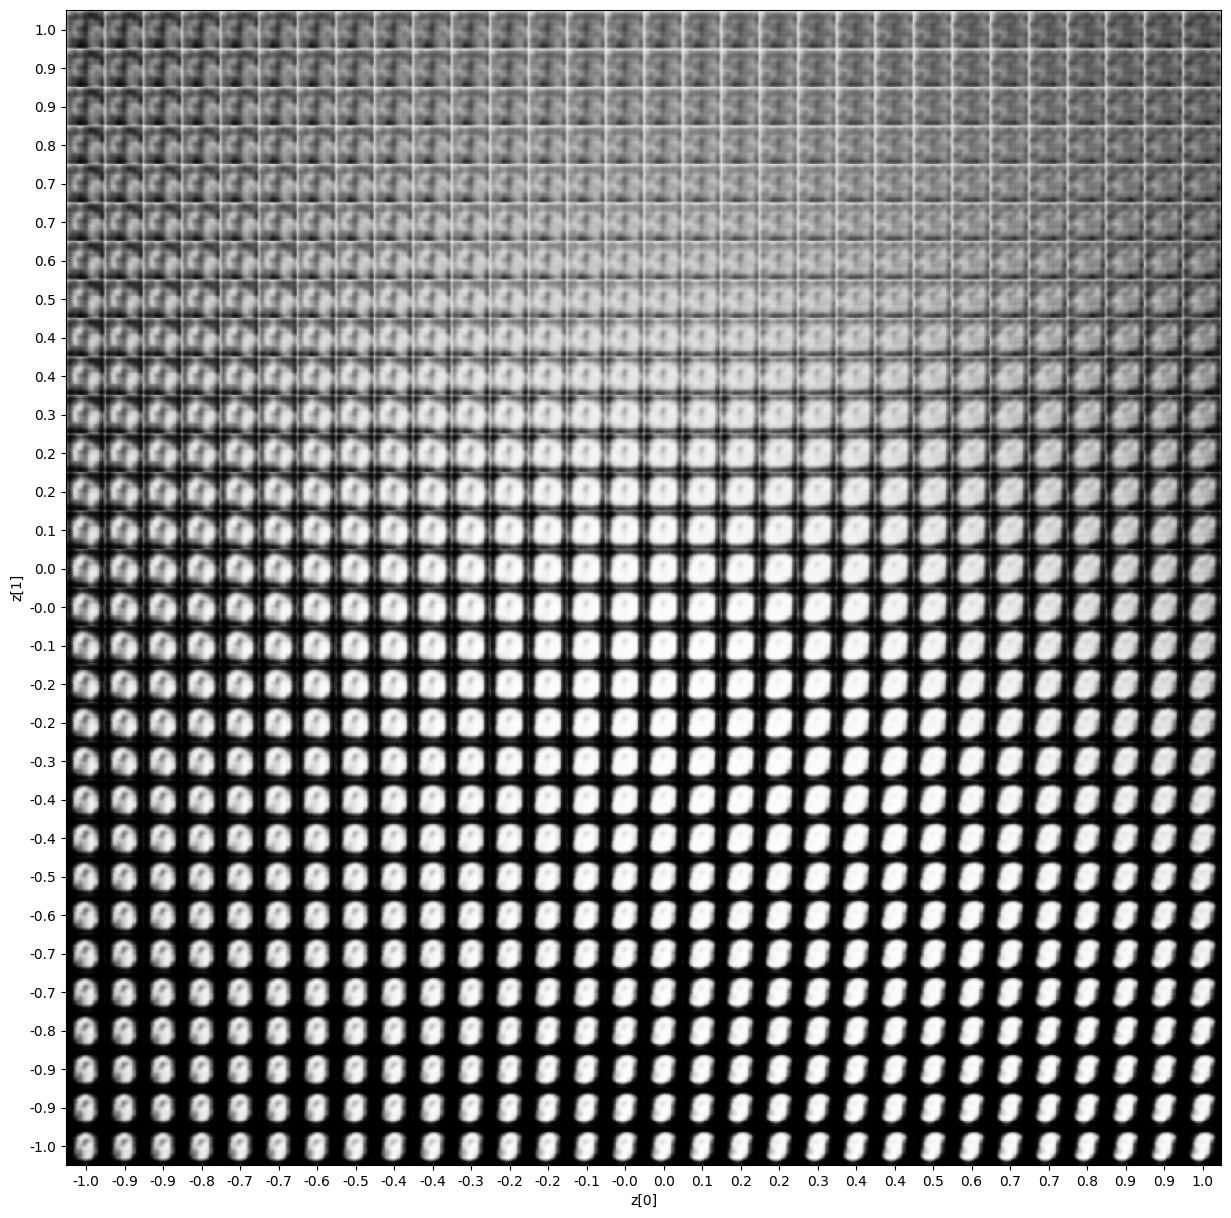

In [73]:
# Display a grid of sampled digits

import matplotlib.pyplot as plt


def plot_latent_space(vae, n=30, figsize=15):
    # display a n*n 2D manifold of digits
    digit_size = 28
    scale = 1.0
    figure = np.zeros((digit_size * n, digit_size * n))
    # linearly spaced coordinates corresponding to the 2D plot
    # of digit classes in the latent space
    grid_x = np.linspace(-scale, scale, n)
    grid_y = np.linspace(-scale, scale, n)[::-1]

    for i, yi in enumerate(grid_y):
        for j, xi in enumerate(grid_x):
            z_sample = np.array([[xi, yi]])
            x_decoded = vae.decoder.predict(z_sample)
            digit = x_decoded[0].reshape(digit_size, digit_size)
            figure[
                i * digit_size : (i + 1) * digit_size,
                j * digit_size : (j + 1) * digit_size,
            ] = digit

    plt.figure(figsize=(figsize, figsize))
    start_range = digit_size // 2
    end_range = n * digit_size + start_range
    pixel_range = np.arange(start_range, end_range, digit_size)
    sample_range_x = np.round(grid_x, 1)
    sample_range_y = np.round(grid_y, 1)
    plt.xticks(pixel_range, sample_range_x)
    plt.yticks(pixel_range, sample_range_y)
    plt.xlabel("z[0]")
    plt.ylabel("z[1]")
    plt.imshow(figure, cmap="Greys_r")
    plt.show()


plot_latent_space(vae)


This graph visualizes the VAE's 2D latent space by decoding points on a grid into MNIST digit images.

It demonstrates:
1.  Semantic Organization: Similar digits are grouped into distinct regions.
2.  Continuity: Moving smoothly across the latent space results in gradual, coherent transformations between digit images.
3.  Generative Capability: The VAE effectively generates meaningful digits from various latent points, confirming a well-structured and continuous latent space.

This shows the VAE successfully learned to represent digits in a compact, interpretable space, allowing for smooth interpolations and new image generation.

Define latent space plot (t-SNE).

In [74]:
from sklearn.manifold import TSNE
def plot_latent_space(z_mean,y):

    # Réduction de dimension avec t-SNE
    tsne = TSNE(n_components=2, init='pca')
    zmean_tsne = tsne.fit_transform(z_mean)


    fig, ax = plt.subplots()
    cmap = plt.get_cmap("tab10")  # Utilisez une carte de couleurs pour différencier les classes
    unique_labels = np.unique(y)
    # Tracer les points pour chaque classe
    for t in unique_labels:
        points = zmean_tsne[y == t]
        ax.scatter(points[:, 0], points[:, 1], color=cmap(t), label=t)

    ax.legend()  # Ajouter une légende
    plt.xlabel('t-SNE caractéristique 1')  # Étiquette pour l'axe x
    plt.ylabel('t-SNE caractéristique 2')  # Étiquette pour l'axe y
    plt.title('Visualisation de l\'espace latent')  # Titre du graphique

    plt.show()  # Afficher le graphique

Plot t-SNE latent space.

313/313 ━━━━━━━━━━━━━━━━━━━━ 6s 12ms/step


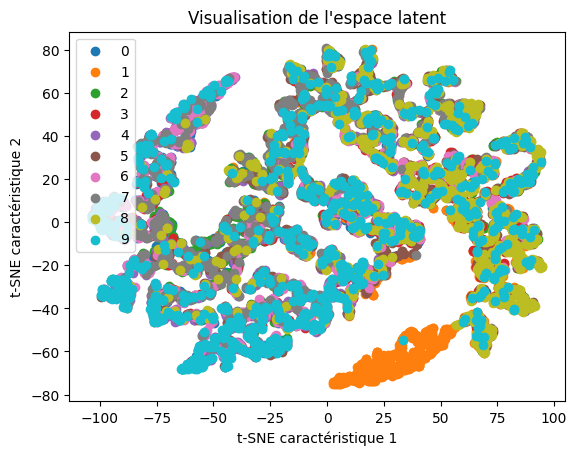

In [75]:
z_mean, _, _ = vae.encoder.predict(x_test)
plot_latent_space(z_mean,y_test )

This t-SNE visualization projects the VAE's latent space (`z_mean`) into 2D, preserving local similarities.

*   Colored Clusters: Points of the same digit label form distinct clusters, showing the VAE learned semantically meaningful features.
*   Semantic Organization: Similar digits are grouped, demonstrating the encoder's effectiveness in differentiating classes.
*   Overlap: Some overlap between clusters (e.g., '4' and '9') is present.
*   Reasons for Overlap: This can be due to visual similarities, inherent MNIST ambiguities, or the strong compression to a 2D latent space.
*   t-SNE Limitations: t-SNE prioritizes local structure, which might not perfectly reflect global distances.

In essence, the t-SNE plot confirms the VAE created a structured latent representation, grouping similar digits effectively even with high compression.

Plot label clusters.

1875/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step


/tmp/ipykernel_1078/1983005918.py:6: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colormap = plt.cm.get_cmap("tab10", len(np.unique(labels)))
/tmp/ipykernel_1078/1983005918.py:10: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  plt.scatter(z_mean[indices, 0], z_mean[indices, 1], c=colormap(label), label=label)


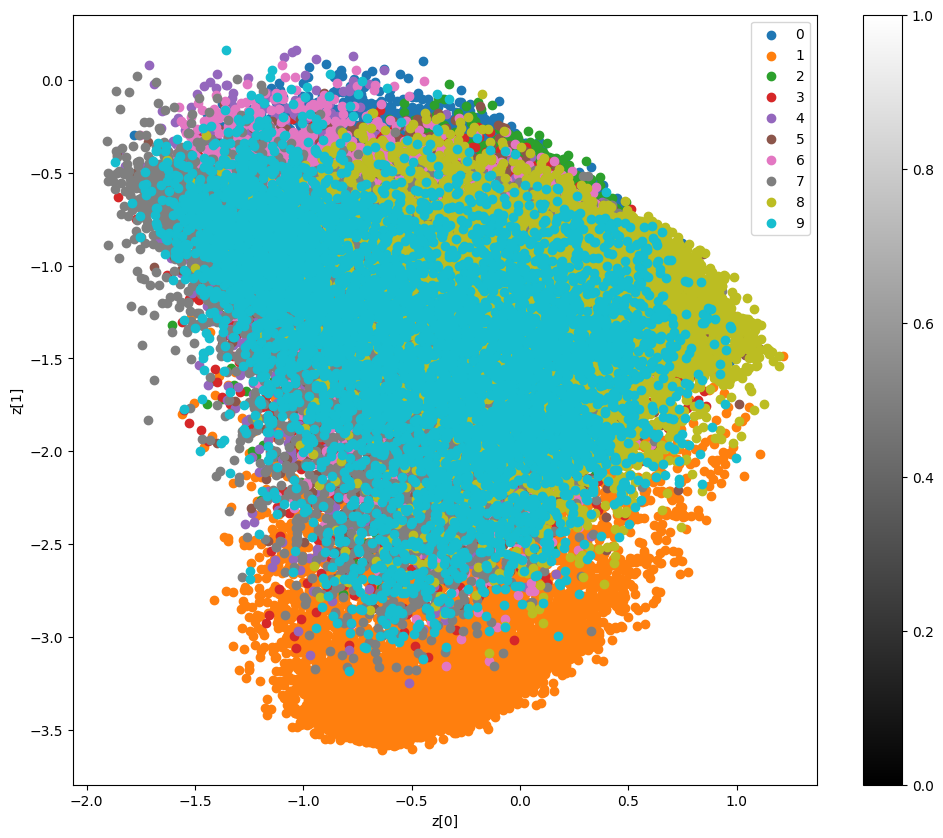

In [76]:

def plot_label_clusters(vae, data, labels):
    # Display a 2D plot of the digit classes in the latent space
    z_mean, _, _ = vae.encoder.predict(data)
    plt.figure(figsize=(12, 10))
    # Define a colormap
    colormap = plt.cm.get_cmap("tab10", len(np.unique(labels)))
    # Plot each data point with a color corresponding to its label
    for label in np.unique(labels):
        indices = labels == label
        plt.scatter(z_mean[indices, 0], z_mean[indices, 1], c=colormap(label), label=label)
    plt.colorbar()
    plt.xlabel("z[0]")
    plt.ylabel("z[1]")
    plt.legend()
    plt.show()

(x_train, y_train), _ = keras.datasets.mnist.load_data()
x_train = np.expand_dims(x_train, -1).astype("float32") / 255

plot_label_clusters(vae, x_train, y_train)

This t-SNE visualization projects the VAE's latent space (`z_mean`) into 2D, preserving local similarities.

*   Colored Clusters: Points of the same digit label form distinct clusters, showing the VAE learned semantically meaningful features.
*   Semantic Organization: Similar digits are grouped, demonstrating the encoder's effectiveness in differentiating classes.
*   Overlap: Some overlap between clusters (e.g., '4' and '9') is present.
*   Reasons for Overlap: This can be due to visual similarities, inherent MNIST ambiguities, or the strong compression to a 2D latent space.
*   t-SNE Limitations: t-SNE prioritizes local structure, which might not perfectly reflect global distances.

In essence, the t-SNE plot confirms the VAE created a structured latent representation, grouping similar digits effectively even with high compression.

Mount Drive and export.

In [ ]:
from google.colab import drive
drive.mount('/content/gdrive')
#%%shell
!jupyter nbconvert --to html '/content/gdrive/MyDrive/Colab Notebooks/AutoEncoders.ipynb'

Drive already mounted at /content/gdrive; to attempt to forcibly remount, call drive.mount("/content/gdrive", force_remount=True).


The Google Drive disk has been successfully mounted and the notebook has been converted to an HTML file, which is now available in the specified path on Drive.